# Handover Project: Statistical Analysis

This notebook performs statistical analysis on the aggregated metrics from the handover project experiments. It focuses on within-subjects comparisons across different report generation conditions.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import os

# Settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Path to the aggregated metrics
CSV_PATH = "/media/kaleb/T7/handover_project/participant_data/analysis/metrics_output/aggregated_metrics.csv"

if not os.path.exists(CSV_PATH):
    print(f"Warning: {CSV_PATH} not found. Please check the path.")

## 1. Load and Prepare Data

In [25]:
df = pd.read_csv(CSV_PATH)


# get derived metric (communcative compression)
df["communicative_compression"] = df["iac_cost_saved"].div(df["token_count"])

# rename conditions
condition_mapping = {
    "user_report": "user-only",
    "full_realization": "FR",
    "task_aware": "TA",
    "task_aware_raw_ablation": "end2end",
    "no_report_task_aware": "TA -user"
}

df.replace(condition_mapping, inplace=True)

# Ensure consistent conditions
conditions = condition_mapping.values()
df = df[df["condition"].isin(conditions)]

# Pivot the data to wide format for within-subjects analysis
df_wide = df.pivot(index='participant_id', columns='condition')

print(f"Loaded metrics for {len(df_wide)} participants.")
df_wide.head()

Loaded metrics for 13 participants.


token_count                                 precision  \
condition               FR   TA TA -user end2end user-only        FR   
participant_id                                                         
501                    359  205      190     284       157  0.838710   
502                    274  171      171     230        70  0.916667   
503                    307  194      153     233       131  0.785714   
504                    341  242      161     273        97  0.656250   
505                    334  194      171     225       247  0.821429   

                                                       ...  \
condition             TA TA -user   end2end user-only  ...   
participant_id                                         ...   
501             0.857143      1.0  0.823529       0.0  ...   
502             1.000000      1.0  0.652174       0.0  ...   
503             1.000000      1.0  0.736842       0.0  ...   
504             0.708333      1.0  0.600000       0.0  ...   
505             0.888889      1.0  0.842105       0.0  ...   

               iac_resource_savings                                       \
condition                        FR      TA TA -user end2end   user-only   
participant_id                                                             
501                          170.17  170.17   170.17   87.17   15.223333   
502                          207.50  207.50   207.50  207.50    0.000000   
503                          174.34  174.34   174.34  174.34   45.670000   
504                          220.01  220.01   137.01  137.01  128.670000   
505                          215.84  215.84   215.84  215.84    0.000000   

               communicative_compression                                \
condition                             FR        TA  TA -user   end2end   
participant_id                                                           
501                             1.632786  2.859366  3.085105  1.771725   
502                             1.971898  3.159649  3.159649  2.414348   
503                             1.478632  2.339897  2.770850  2.305322   
504                             1.953109  2.752107  3.434845  2.355348   
505                             1.642635  2.828041  3.208421  2.438400   

                          
condition      user-only  
participant_id            
501             0.626900  
502             0.000000  
503             1.212748  
504             4.552062  
505             1.927126  

[5 rows x 75 columns]

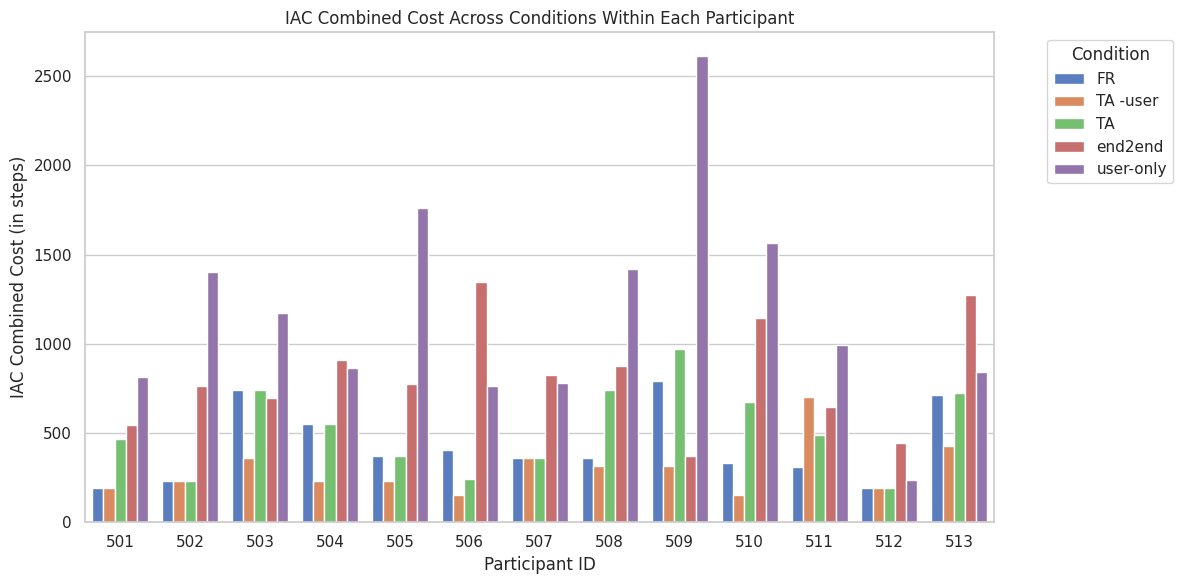

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='participant_id', y='iac_combined_cost', hue='condition')
plt.title('IAC Combined Cost Across Conditions Within Each Participant')
plt.ylabel('IAC Combined Cost (in steps)')
plt.xlabel('Participant ID')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Statistical Helper Functions

We use non-parametric tests as the sample size is small and we cannot assume normality.
- **Wilcoxon Signed-Rank Test**: For 2-group within-subjects comparisons.
- **Friedman Test**: For 3+ group within-subjects comparisons.
- **Kendall's W**: Effect size for Friedman test.
- **Rank-Biserial Correlation (r)**: Effect size for Wilcoxon test.

In [39]:
def calculate_kendall_w(friedman_stat, n, k):
    """Calculates Kendall's W for Friedman test."""
    return friedman_stat / (n * (k - 1))

def calculate_rank_biserial(wilcoxon_stat, n):
    """Calculates Rank-Biserial Correlation (r) for Wilcoxon test."""
    # r = 1 - (2 * W / (n * (n + 1)))
    # Or more robustly via Z: r = Z / sqrt(N)
    # Scipy doesn't return Z directly, but we can approximate or use the formula below
    # Using a simpler r = Z / sqrt(n) approach if we had Z, 
    # but for Wilcoxon, common r = 1 - (4 * W / (n * (n + 1)))
    # Here we'll use a simplified version: r = 1 - (2 * W / total_rank_sum)
    total_ranks = n * (n + 1) / 2
    return 1 - (2 * wilcoxon_stat / total_ranks)

def annotate_stats(ax, p_value, x1, x2, y, h):
    """Adds significance markers to a plot."""
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "n.s."
    
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='k')
    ax.text((x1+x2)*.5, y+h, sig, ha='center', va='bottom', color='k', fontsize=12)



## 3. Analysis: Precision, Recall, and F1

Comparison across all conditions. We start with a Friedman test across all conditions and perform post-hoc Wilcoxon follow-up comparisons.

In [28]:
metrics_pr = ['precision', 'recall', 'f1']
results_pr = []
posthoc_pr_results = []

pairs = [
    ("user-only", "TA"),
    ("FR", "TA"),
    ("TA", "end2end"),
    ("TA", "TA -user")
]

for metric in metrics_pr:
    data = [df_wide[metric][c] for c in conditions]

    # Remove participants with any NaNs in these columns
    mask = ~(data[0].isna() | data[1].isna() | data[2].isna())
    data = [d[mask] for d in data]
    if len(data[0]) < 2:
        continue
        
    stat, p = stats.friedmanchisquare(*data)
    w = calculate_kendall_w(stat, len(data[0]), len(conditions))
    
    results_pr.append({
        'Metric': metric,
        'Friedman Stat': stat,
        'p-value': p,
        'Kendall\'s W': w
    })
    
    # Post-hoc if significant
    if p < 0.05:
        p_vals = []
        medians = []
        for p1, p2 in pairs:
            pair_mask = ~(df_wide[metric][p1].isna() | df_wide[metric][p2].isna())
            _, pp = stats.wilcoxon(df_wide[metric][p1][pair_mask], df_wide[metric][p2][pair_mask])
            p_vals.append(pp)
            medians.append((df_wide[metric][p1][pair_mask].median(), df_wide[metric][p2][pair_mask].median()))
        
        # Holm correction
        _, p_adj, _, _ = multipletests(p_vals, method='holm')
        
        for i, pair in enumerate(pairs):
            posthoc_pr_results.append({
                'Metric': metric,
                'Comparison': f"{pair[0]} vs {pair[1]}",
                'Median 1': medians[i][0],
                'Median 2': medians[i][1],
                'p-adj': p_adj[i]
            })

results_pr_df = pd.DataFrame(results_pr)
posthoc_pr_df = pd.DataFrame(posthoc_pr_results)

print("Precision / Recall / F1 Statistical Results (Friedman Test):")
display(results_pr_df)
if not posthoc_pr_df.empty:
    print("\nPost-hoc Wilcoxon (Holm-corrected):")
    display(posthoc_pr_df)

Precision / Recall / F1 Statistical Results (Full vs Task Aware):


,Metric,FR median,TA median,Wilcoxon W,p-value,Effect Size (r)
0,precision,0.787879,0.857143,0.0,0.000244,1.000000
1,recall,0.675000,0.516129,1.0,0.000488,0.978022
2,f1,0.741935,0.666667,6.0,0.003418,0.868132


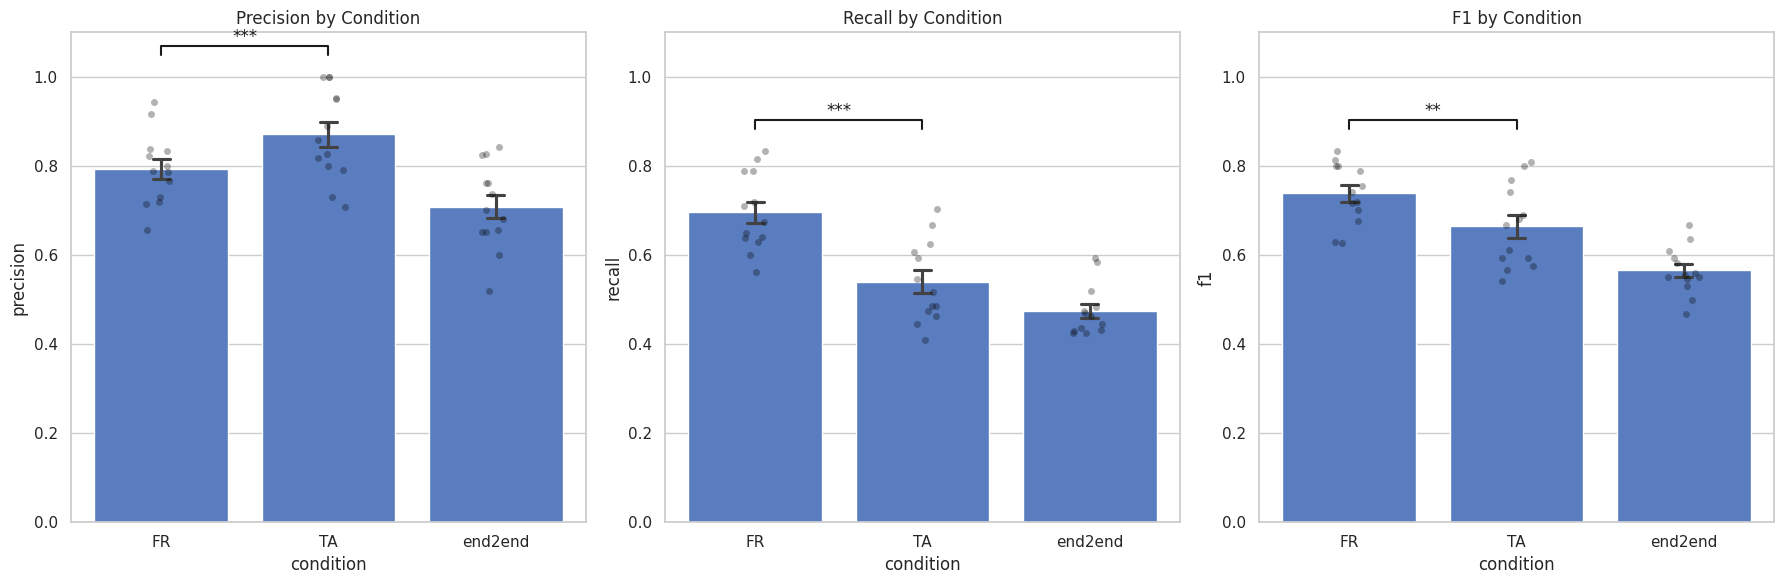

In [29]:
# Visualization for P/R/F1
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_df = df
conditions_list = list(conditions)

for i, metric in enumerate(metrics_pr):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', order=conditions_list)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3, order=conditions_list)
    
    axes[i].set_title(f"{metric.capitalize()} by Condition")
    axes[i].set_ylim(0, 1.35)
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_pr_df[posthoc_pr_df['Metric'] == metric]
    if not metric_posthoc.empty:
        max_y = df[metric].max()
        y_offset = 0.08
        curr_y = max_y + y_offset
        
        idx_map = {c: idx for idx, c in enumerate(conditions_list)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            if p_adj < 0.05:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.4

plt.tight_layout()
plt.show()

## 4. Analysis: IAC and Costs

Comparison across `full_realization`, `task_aware`, and `user_report`.

In [30]:
from itertools import combinations

metrics_iac = ['iac_combined_cost', 'iac_misinformation_cost', 'iac_cost_saved', "communicative_compression"]
results_iac = []
posthoc_results = []

pairs = [
    ("user-only", "TA"),
    ("FR", "TA"),
    ("TA", "end2end"),
    ("TA", "TA -user")
]


for metric in metrics_iac:
    data = [df_wide[metric][c] for c in conditions]

    # Remove participants with any NaNs in these columns
    mask = ~(data[0].isna() | data[1].isna() | data[2].isna())
    data = [d[mask] for d in data]
    if len(data[0]) < 2:
        continue
        
    stat, p = stats.friedmanchisquare(*data)
    w = calculate_kendall_w(stat, len(data[0]), len(conditions))
    
    results_iac.append({
        'Metric': metric,
        'Friedman Stat': stat,
        'p-value': p,
        'Kendall\'s W': w
    })
    
    # Post-hoc if significant
    if p < 0.05:
        p_vals = []
        medians = []
        for p1, p2 in pairs:
            pair_mask = ~(df_wide[metric][p1].isna() | df_wide[metric][p2].isna())
            _, pp = stats.wilcoxon(df_wide[metric][p1][pair_mask], df_wide[metric][p2][pair_mask])
            p_vals.append(pp)
            medians.append((df_wide[metric][p1][pair_mask].median(), df_wide[metric][p2][pair_mask].median()))
        
        # Holm correction
        _, p_adj, _, _ = multipletests(p_vals, method='holm')
        
        for i, pair in enumerate(pairs):
            posthoc_results.append({
                'Metric': metric,
                'Comparison': f"{pair[0]} vs {pair[1]}",
                'Median 1': medians[i][0],
                'Median 2': medians[i][1],
                'p-adj': p_adj[i]
            })

results_iac_df = pd.DataFrame(results_iac)
posthoc_df = pd.DataFrame(posthoc_results)

print("IAC / Cost Statistical Results (Friedman Test):")
display(results_iac_df)
if not posthoc_df.empty:
    print("\nPost-hoc Wilcoxon (Holm-corrected):")
    display(posthoc_df)

IAC / Cost Statistical Results (Friedman Test):


,Metric,Friedman Stat,p-value,Kendall's W
0,iac_combined_cost,36.409836,2.382961e-07,0.700189
1,iac_misinformation_cost,28.052632,1.217029e-05,0.539474
2,iac_cost_saved,34.684211,5.393474e-07,0.667004
3,communicative_compression,28.341085,1.063684e-05,0.545021



Post-hoc Wilcoxon (Holm-corrected):


,Metric,Comparison,Median 1,Median 2,p-adj
0,iac_combined_cost,user-only vs TA,995.860000,491.500000,0.000977
1,iac_combined_cost,FR vs TA,361.200000,491.500000,0.046875
2,iac_combined_cost,TA vs end2end,491.500000,773.200000,0.042969
3,iac_combined_cost,TA vs TA -user,491.500000,233.200000,0.029297
4,iac_misinformation_cost,user-only vs TA,173.000000,120.000000,0.041016
5,iac_misinformation_cost,FR vs TA,60.000000,120.000000,0.125000
6,iac_misinformation_cost,TA vs end2end,120.000000,180.000000,0.041016
7,iac_misinformation_cost,TA vs TA -user,120.000000,0.000000,0.039062
8,iac_cost_saved,user-only vs TA,158.870000,548.640000,0.000977
9,iac_cost_saved,FR vs TA,548.640000,548.640000,0.250000


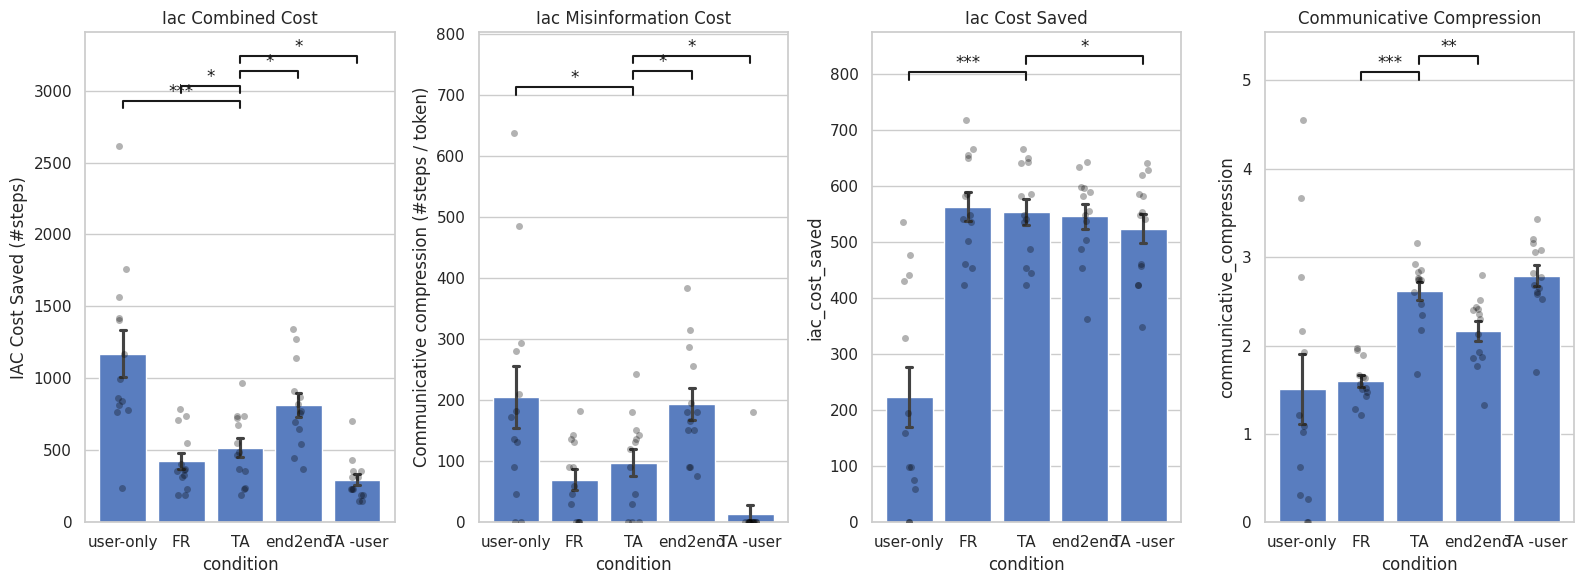

In [31]:
# Visualization for IAC Metrics
fig, axes = plt.subplots(1, len(metrics_iac), figsize=(16, 6))
if len(metrics_iac) == 1: axes = [axes]

# Create a 'raw' condition dataframe to include in the plot
# raw_df = df.drop_duplicates(subset=['participant_id']).copy()
# raw_df['condition'] = 'raw'
# for m in metrics_iac:
#     if f'raw_{m}' in raw_df.columns:
#         raw_df[m] = raw_df[f'raw_{m}']
# plot_df = pd.concat([df[df['condition'].isin(['user_report', 'task_aware', 'full_realization'])], raw_df], ignore_index=True)
plot_df = df


for i, metric in enumerate(metrics_iac):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', 
                order=conditions)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3,
                  order=conditions)
    
    axes[i].set_title(f"{metric.replace('_', ' ').title()}")
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
    if not metric_posthoc.empty:
        max_y = df[metric].max()
        # Simple logic for annotations (can be refined)
        y_offset = max_y * 0.1
        curr_y = max_y + y_offset
        
        # Mapping condition names to plot indices (order: raw, user_report, task_aware, full_realization)
        idx_map = {c: idx for idx, c in enumerate(conditions)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            if p_adj < 0.05:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.4

axes[0].set_ylabel("IAC Cost Saved (#steps)")
axes[1].set_ylabel("Communicative compression (#steps / token)")

plt.tight_layout()
plt.show()

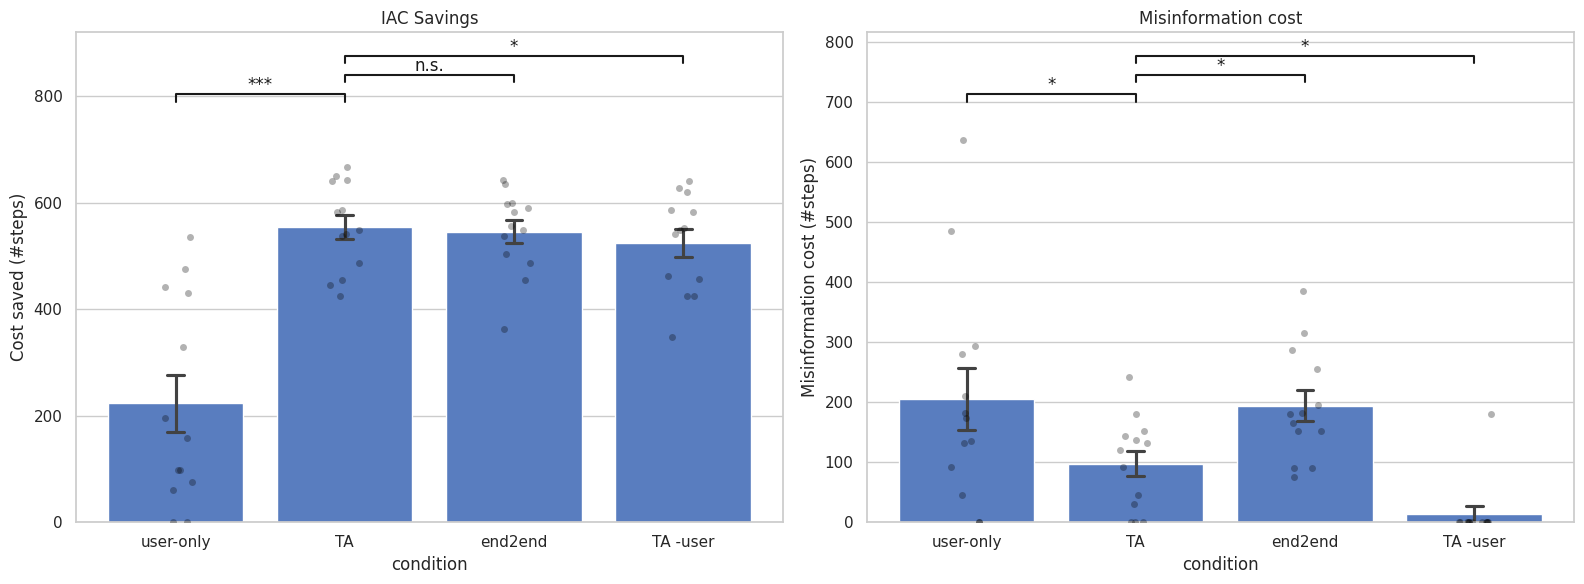

In [32]:
# Create separate figures for pub
conditions_to_plot = ["user-only", "TA", "end2end", "TA -user"]
plot_df = df[df['condition'].isin(conditions_to_plot)]
metrics_to_plot = ["iac_cost_saved", "iac_misinformation_cost"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 6))
if len(metrics_to_plot) == 1: axes = [axes]

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', 
                order=conditions_to_plot)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3,
                  order=conditions_to_plot)
    
    axes[i].set_title(f"{metric.replace('_', ' ').title()}")
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
    if (metric != "iac_combined_cost") and not metric_posthoc.empty:
        max_y = df[metric].max()
        # Simple logic for annotations (can be refined)
        y_offset = max_y * 0.1
        curr_y = max_y + y_offset
        
        # Mapping condition names to plot indices
        idx_map = {c: idx for idx, c in enumerate(conditions_to_plot)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            # if p_adj < 0.05:
            if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.5


axes[0].set_ylabel("Cost saved (#steps)")
axes[0].set_title("IAC Savings")

axes[1].set_ylabel("Misinformation cost (#steps)")
axes[1].set_title("Misinformation cost")

plt.tight_layout()
plt.show()

In [76]:
def annotate_stats_inverted(ax, p_value, x1, x2, y, h):
    """Adds significance markers to a plot."""
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        # return
        sig = "n.s."
    
    ax.plot([x1, x1, x2, x2], [y, y-h, y-h, y], lw=1.5, c='k')
    ax.text((x1+x2)*.5, y-h, sig, ha='center', va='top', color='k', fontsize=12)

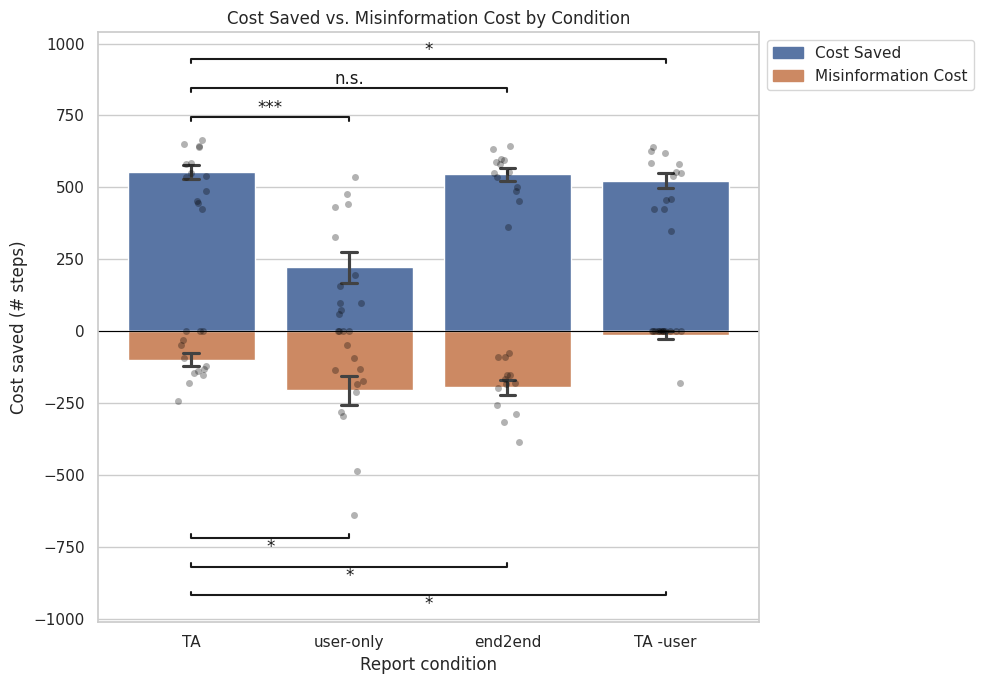

In [104]:
import matplotlib.patches as mpatches


sns.set_theme(style="whitegrid")
df["inverse_misinfo_cost"] = df["iac_misinformation_cost"] * -1
conditions_to_plot = ["TA", "user-only", "end2end", "TA -user"]
plot_df = df[df['condition'].isin(conditions_to_plot)]
# metrics_to_plot = ["iac_cost_saved", "iac_misinformation_cost"]

fig, ax = plt.subplots(figsize=(10, 7))
# fig, ax = plt.subplots()
x = list(range(len(conditions_to_plot)))
width = 0.35

sns.barplot(data=plot_df, x='condition', y="iac_cost_saved", ax=ax, capsize=.1, errorbar='se', 
                order=conditions_to_plot,
                # color="#6929c4"
                )
sns.stripplot(data=plot_df, x='condition', y="iac_cost_saved", ax=ax, color='black', alpha=0.3,
                order=conditions_to_plot)
    
sns.barplot(data=plot_df, x='condition', y="inverse_misinfo_cost", ax=ax, capsize=.1, errorbar='se', 
                order=conditions_to_plot,
                # color="#1192e8"
                )
sns.stripplot(data=plot_df, x='condition', y="inverse_misinfo_cost", ax=ax, color='black', alpha=0.3,
                order=conditions_to_plot)
    

# # Add post-hoc significance markers if available
idx_map = {c: idx for idx, c in enumerate(conditions_to_plot)}

# for positive (cost_saved)
metric = "iac_cost_saved"
metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]

max_y = plot_df[metric].max()
y_offset = max_y * 0.1
curr_y = max_y + y_offset

for _, row in metric_posthoc.iterrows():
    p_adj = row['p-adj']
    p1_name, p2_name = row['Comparison'].split(' vs ')
    if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
        annotate_stats(ax, p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
        curr_y += (y_offset * 1.5)

# for negative (misinfo cost)
metric = "iac_misinformation_cost"
metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
max_y = plot_df[metric].max()
# y_offset = max_y * 0.1
curr_y = max_y * -1 - y_offset
for _, row in metric_posthoc.iterrows():
    p_adj = row['p-adj']
    p1_name, p2_name = row['Comparison'].split(' vs ')
    if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
        annotate_stats_inverted(ax, p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
        curr_y -= (y_offset * 1.5)


ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Cost saved (# steps)")
ax.set_xlabel("Report condition")
ax.set_title("Cost Saved vs. Misinformation Cost by Condition")
# ax.legend()
# Grab the colors seaborn assigned to each set of bars
cost_saved_color = ax.patches[0].get_facecolor()
misinfo_color = ax.patches[len(conditions_to_plot)].get_facecolor()

cost_saved_patch = mpatches.Patch(color=cost_saved_color, label='Cost Saved')
misinfo_patch = mpatches.Patch(color=misinfo_color, label='Misinformation Cost')

ax.legend(handles=[cost_saved_patch, misinfo_patch], bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## 5. Descriptives: Content categorization of user-onlys


In [248]:
CATEGORY_CSV = "/media/kaleb/T7/handover_project/participant_data/analysis/content_categorization/aggregated_content_categorization.csv"

content_df = pd.read_csv(CATEGORY_CSV)
content_df = content_df.set_index("participant_id")

content_props = content_df.copy()
content_props["total tokens"] = content_props.sum(axis=1)
content_props = content_props.drop(
                    columns=["total tokens"]
                ).div(
                    content_props["total tokens"], axis=0
                )

content_props

,state,knowledge,ambiguous,meta
participant_id,,,,
501,0.305556,0.659722,0.000000,0.034722
502,0.515152,0.181818,0.303030,0.000000
503,0.336066,0.475410,0.188525,0.000000
504,0.417582,0.230769,0.120879,0.230769
505,0.426087,0.573913,0.000000,0.000000
506,0.554839,0.322581,0.122581,0.000000
507,0.204082,0.714286,0.000000,0.081633
508,0.067039,0.346369,0.413408,0.173184
509,0.407666,0.439024,0.128920,0.024390


<Axes: title={'center': 'Content makeup in user reports by category'}, xlabel='content label', ylabel='proportion of tokens in report'>

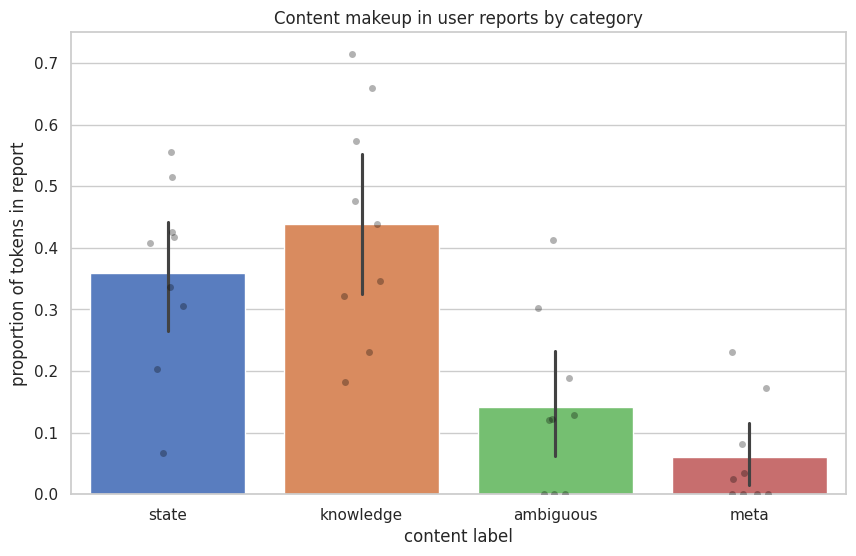

In [ ]:
ax = sns.barplot(data=content_props)
ax.set_xlabel("content label")
ax.set_ylabel("proportion of tokens in report")
ax.set_title("Content makeup in user-onlys by category")
sns.stripplot(data=content_props, ax=ax, color='black', alpha=0.3)

Text(0.5, 1.0, 'Content makeup in user reports by user')

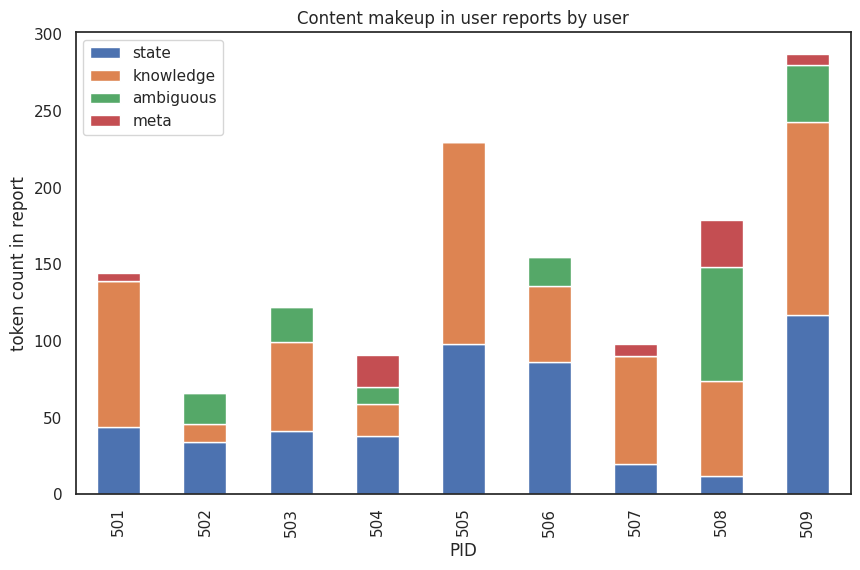

In [ ]:
sns.set(style="white")
ax = content_df.plot(kind="bar", stacked=True)
ax.set_xlabel("PID")
ax.set_ylabel("token count in report")
ax.set_title("Content makeup in user-onlys by user")

notes from meeting with brad
- partial credit wherever possible 
    - manually inspect main generation pipeline
    - manually inspect/redo/verify content classification
- framing/narrative is good, can move forward with writing
